# Бустинг 

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/iad/ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Подготовка



*   Разделим выборку на train, val, test (80%, 10%, 10%)
*   Выдерем salary_in_usd в качестве таргета
*   Найдем и удалим признак, из-за которого возможен лик в данных


In [ ]:
from sklearn.model_selection import train_test_split


y=df['salary_in_usd']

X = df.drop(columns=['salary_in_usd', 'salary', 'salary_currency'])
X_train, Xx, y_train, yy = train_test_split(X, y, test_size=0.2, random_state=0) # трейн 80, хх уу = 20
X_val, X_test, y_val, y_test = train_test_split(Xx, yy, test_size=0.5, random_state=0) # половина от 20 - 10


## Линейная модель


*   Закодируем категориальные  признаки с помощью OneHotEncoder
*   Обучим модель линейной регрессии
*   Оценим  качество через MAPE и RMSE


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder




categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns


enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(X_train[categorical_features])

encoded_cols = enc.get_feature_names_out(categorical_features)

X_train_cat_encoded = enc.transform(X_train[categorical_features])
X_val_cat_encoded = enc.transform(X_val[categorical_features])
X_test_cat_encoded = enc.transform(X_test[categorical_features])

X_train_cat_df = pd.DataFrame(X_train_cat_encoded, index=X_train.index, columns=encoded_cols)
X_val_cat_df = pd.DataFrame(X_val_cat_encoded, index=X_val.index, columns=encoded_cols)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, index=X_test.index, columns=encoded_cols)


In [16]:
lr = LinearRegression()
lr.fit(X_train_cat_df, y_train)

y_pred_lr = lr.predict(X_test_cat_df)

In [17]:
mape = mean_absolute_percentage_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('MAPE: ',mape)
print('RMSE: ', rmse )

MAPE:  0.3678150120313704
RMSE:  54531.24443831725


## XGboost

Начнем с библиотеки xgboost.

Обучим модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оценим качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [18]:
from sklearn.model_selection import GridSearchCV
from xgboost.sklearn import XGBRegressor

param_grid = {
    'max_depth': [3, 5, 7, 8, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 150, 200, 250, 300],
    'gamma': [0, 0.1, 0.2, 0,35, 0.5]
}

grid = GridSearchCV(XGBRegressor(random_state=0), param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
grid.fit(X_val_cat_df, y_val)

best_params = grid.best_params_
print("Лучшие параметры:", best_params)

Лучшие параметры: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


In [19]:
params = {
    'max_depth': 7,
    'learning_rate': 0.1,
    'n_estimators': 300,
    'gamma': 0,
    'subsample': 0.5,
    'colsample_bytree': 0.8,
    'random_state': 0,
    'eval_metric': 'rmse'
}

model = XGBRegressor(**params)

In [20]:
%%time
model.fit(X_train_cat_df, y_train, eval_set=[(X_val_cat_df, y_val)], verbose=False)


CPU times: user 2.41 s, sys: 14 ms, total: 2.42 s
Wall time: 1.29 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=0, ...)

In [21]:
%%time
y_pred = model.predict(X_test_cat_df)


CPU times: user 54.2 ms, sys: 1e+03 µs, total: 55.2 ms
Wall time: 52.3 ms


In [22]:
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [23]:
print("MAPE:", mape)
print("RMSE: ",rmse)
# print("Train time: ", train_time )
# print("Predict time: ", predict_time )

MAPE: 0.33141615986824036
RMSE:  53725.90347309201


почему то стало меньше....

## CatBoost

Теперь библиотека CatBoost.

Обучим модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оценим качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [24]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00


In [25]:
from time import time
from catboost import CatBoostRegressor

param_grid = {
    'depth': [3, 5, 7, 8, 10],
    'learning_rate':  [0.01, 0.1, 0.2],
    'iterations': [100,200, 350, 500, 800]
}

model = CatBoostRegressor(random_seed=0, verbose=0)

grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
grid.fit(X_train_cat_df, y_train)

best_model = grid.best_estimator_

# print("Train time: ", train_time )
# print("Predict time: ", predict_time )

In [26]:
%%time
best_model.fit(X_train_cat_df, y_train)


CPU times: user 6.81 s, sys: 947 ms, total: 7.76 s
Wall time: 7.7 s


In [27]:
%%time
y_pred = best_model.predict(X_test_cat_df)


CPU times: user 11.4 ms, sys: 1.01 ms, total: 12.4 ms
Wall time: 36.8 ms


In [28]:
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Лучшие параметры: ", grid.best_params_)
print("MAPE: ", mape)
print("RMSE: ", rmse)

Лучшие параметры:  {'depth': 10, 'iterations': 500, 'learning_rate': 0.2}
MAPE:  0.3441916874441776
RMSE:  53770.93177531494


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [ ]:
from catboost import Pool


# print(X_train_cat_df)
train_pool = Pool(X_train, y_train, cat_features=np.array(categorical_features))
val_pool = Pool(X_val, y_val, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

param_grid = {
    'depth': [3, 5, 7, 8, 10],
    'learning_rate':  [0.01, 0.1, 0.2],
    'iterations': [100,200, 350, 500, 800],
    'l2_leaf_reg': [1, 3,5]
}

model = CatBoostRegressor(random_seed=0, eval_metric='RMSE',early_stopping_rounds=20,verbose=0)


grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
grid.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=categorical_features)

best_model = grid.best_estimator_

In [ ]:
best_params = grid.best_params_
print("Лучшие параметры:", best_params)

In [30]:
%%time
best_model.fit(train_pool)

CPU times: user 422 ms, sys: 114 ms, total: 536 ms
Wall time: 1.48 s


In [31]:
%%time
y_pred = best_model.predict(test_pool)

CPU times: user 1.25 ms, sys: 8 µs, total: 1.26 ms
Wall time: 1.27 ms


In [33]:
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Лучшие параметры: ", grid.best_params_)
print("MAPE: ", mape)
print("RMSE: ", rmse)

Лучшие параметры:  {'depth': 5, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.2}
MAPE:  0.34584976271201673
RMSE:  52267.15803022747


 # -- YOUR ANSWER HERE --

## LightGBM

И наконец библиотека LightGBM - используем `LGBMRegressor`, снова подберем гиперпараметры, оценим качество и скорость.


In [ ]:
from lightgbm import LGBMRegressor


params = {
    'max_depth' : [1, 3, 5, 7] ,
    'learning_rate' : [0.05, 0.1, 0.15, 0.2] ,
    'n_estimators': [100, 350, 500],
    'num_leaves': [20, 50, 100]
    
}



lgbm = LGBMRegressor(random_state=0, force_col_wise=True)
grid = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error', n_jobs=-1, verbose=1)
grid.fit(X_train_cat_df, y_train)

Fitting 3 folds for each of 225 candidates, totalling 675 fits
[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 35
[LightGBM] [Info] Start training from score 136404.995340


GridSearchCV(cv=3, estimator=LGBMRegressor(force_col_wise=True, random_state=0),
             n_jobs=-1,
             param_grid={'depth': [3, 5, 7, 8, 10],
                         'iterations': [100, 200, 350, 500, 800],
                         'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.01, 0.1, 0.2]},
             scoring='neg_mean_absolute_percentage_error', verbose=1)

In [37]:
best_model = grid.best_estimator_

In [41]:
%%time
best_model.fit(X_train_cat_df, y_train)

[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 35
[LightGBM] [Info] Start training from score 136404.995340
CPU times: user 105 ms, sys: 4.99 ms, total: 110 ms
Wall time: 111 ms


LGBMRegressor(depth=3, force_col_wise=True, iterations=100, l2_leaf_reg=1,
              random_state=0)

In [43]:
%%time
y_pred = best_model.predict(X_test_cat_df)

[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
[LightGBM] [Warning] Unknown parameter: depth
CPU times: user 10.5 ms, sys: 0 ns, total: 10.5 ms
Wall time: 11.5 ms


In [ ]:

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Лучшие параметры: ", grid.best_params_)
print("MAPE: ", mape)
print("RMSE: ", rmse)

Лучшие параметры:  {'depth': 3, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
MAPE:  0.3428469079634565
RMSE:  53382.23781570992


##  Сравнение и выводы

Какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

CatBoost без использования Pool и XGBoost продемонстрировали наилучшие результаты по MAPE, в то время как остальные модели показали несколько худшие показатели. По RMSE CatBoost с использованием Pool показал наилучший результат, за ним следует LightGBM, а CatBoost без Pool и XGBoost имеют схожие результаты, около 53034.

LightGBM оказалась самой быстрой в обучении, при этом её скорость была примерно на уровне XGBoost и CatBoost без Pool. CatBoost с Pool обучался значительно медленнее всех остальных моделей.

По скорости предсказания наилучшие результаты показал CatBoost с Pool (0.002 секунды). На втором месте расположились XGBoost и CatBoost без Pool, тогда как LightGBM оказался самым медленным.

Гиперпараметры варьируются для различных моделей. Например, XGBoost и CatBoost с Pool используют глубокие деревья глубиной 7 и большое количество итераций (300), тогда как CatBoost без Pool и LightGBM применяют неглубокие деревья глубиной 1. LightGBM компенсирует это достаточным количеством листьев (31) и увеличенным числом итераций (300). XGBoost использует более высокий learning_rate (0.1) по сравнению с CatBoost (0.2).

Кроме того, CatBoost с Pool применяет более сильную регуляризацию (l2leafreg=1), тогда как CatBoost без Pool использует более слабую регуляризацию (l2leafreg=1).

# Кластеризация

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [45]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [ ]:

ratingsT = ratings.T

Выкенем строку под названием `user`.

In [ ]:

ratingsT = ratingsT.drop('user')

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [ ]:

ratings = ratingsT.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
mf doom,0.0,0.0,0.0,0.0,0.0,0.0,0.055286,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##  Первая кластеризация

Применим KMeans с 5ю кластерами, сохраните полученные лейблы

Выведем размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [ ]:
from sklearn.cluster import KMeans


km = KMeans(n_clusters=5, random_state=42)
clusters = km.fit_predict(ratings)

print(pd.Series(clusters).value_counts())


3    882
0    115
4      1
2      1
1      1
Name: count, dtype: int64


 не самая полезная классификация - почти все исполнители в 3м кластере, а также есть кластеры где по 1му исполнителю. Это нам ничего не говорит. Это может происходить потому, что каждый пользователь слушает совсем немного исполнителей, а не всех подряд. В итоге у многих пользователей получаются очень похожие пустые профили, и модель считает их одинаковыми и относит в один кластер.

## Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведем исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [ ]:

from collections import Counter
cluster_counts = Counter(clusters)
unique_clusters = [cid for cid, count in cluster_counts.items() if count == 1]
unique_artist_indices = [i for i, cid in enumerate(clusters) if cid in unique_clusters]
singleton_artists = ratings.index[unique_artist_indices]

print("Исполнители, находящиеся в одиночных кластерах:", singleton_artists.tolist())

Исполнители, находящиеся в одиночных кластерах: ['the beatles', 'niИ', '日dir en grey']


Почему именно The Beatles выделяется?

In [ ]:

artist_listener_share = (ratings != 0).sum(axis=1) / ratings.shape[1]

mean_listener_share = artist_listener_share.mean()

print("Доля пользователей по исполнителям: ", artist_listener_share)
print("Средняя доля прослушивания: ", mean_listener_share)

Доля пользователей по исполнителям:  the beatles           0.3342
radiohead             0.2778
deathcab for cutie    0.1862
coldplay              0.1682
modest mouse          0.1628
                       ...  
michal w. smith       0.0094
群星                    0.0094
agalloch              0.0094
meshuggah             0.0094
yellowcard            0.0094
Length: 1000, dtype: float64
Средняя доля прослушивания:  0.026826200000000005


У The Beatles самая большая популярность так как их слушает почти каждый третий пользователь. У них также самая высокая средняя доля прослушиваний. Возможно, из-за этого KMeans считает их выделяющимися и не похожими на остальных, потому что у них слишком много прослушиваний по сравнению с другими


## Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуем данные при помощи `normalize`.

In [ ]:
from sklearn.preprocessing import normalize


ratings_normalized = normalize(ratings)

Применим KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [ ]:

k_means = KMeans(n_clusters=5, random_state=42)
clusters = k_means.fit_predict(ratings_normalized)

print(pd.Series(clusters).value_counts())

4    486
1    162
3    140
2    133
0     79
Name: count, dtype: int64


 да, потому что нет теперь бесполезных кластеров из 1-го исполнителя, классификация более сбалансированная, теперь можно подумать, что алгоритм какие-то закономерности вынес.

## Центроиды

Выведем для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Что можно сказать о смысле кластеров?

In [ ]:
from scipy.spatial.distance import cosine



similar_artists = {}

for cluster_id, centroid in enumerate(k_means.cluster_centers_):
    similarities = []
    for artist_id, artist_vector in enumerate(ratings_normalized):
        similarity = cosine(centroid, artist_vector)
        artist_name = ratings.index[artist_id]
        similarities.append((artist_name, similarity))
    closest_10 = sorted(similarities, key=lambda pair: pair[1])[:10]
    similar_artists[cluster_id] = [name for name, _ in closest_10]

for cluster_num, artist_list in similar_artists.items():
    print(f"Кластер {cluster_num}:")
    print(', '.join(artist_list))
    print()

Кластер 0:
nas, jay-z, kanye west, lupe the gorilla, a tribe called quest, the roots featuring d'angelo, gangstarr, little brother, lil' wayne, murs and 9th wonder

Кластер 1:
fall out boy, the all-americian rejects, paramore, kelly clarkson, john mayer, the fray, maroon5, dashboard confesssional, somethings corporate, coldplay

Кластер 2:
brand new, blink-182, alkaline trio, against me!, underoath, descendents, new found glory, less than jake, thrice, chiodos

Кластер 3:
the beatles, the rolling stones, dylan. bob, who, led zeppelin., miles davis., simon and garfunkel, young, neil, pink fluid, velvet underground

Кластер 4:
radiohead, the arcade fire, the shins, sufjan stevens, belle and sebastian, broken social scene, the pixies, animal collective, modest mouse, spoon



 наконец-то задания интересные. На первый взгляд я бы их соединила по жанру

0 кластер - артисты в жанре хип-хоп

1 - поп рок (fall out boy, coldplay, maroon5)

2 - панк рок

3 - классический рок

4 - тяжело, потому что радиохэд и sufjan stevens явно не в одном жанре исполнители. я бы сказала, что это chamber pop, инди рок

##  Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Построим точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. 

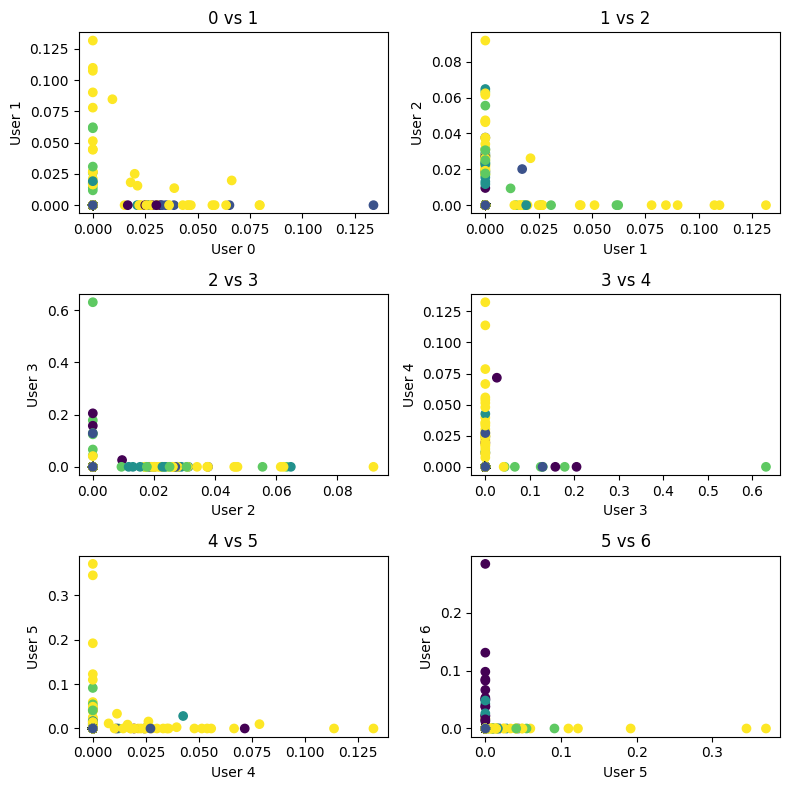

In [ ]:
import matplotlib.pyplot as plt


figures, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8))
plots = [ax for row in axes for ax in row]

for plot_index in range(6):
    horizontal = ratings_normalized[:, plot_index]
    vertical = ratings_normalized[:, plot_index + 1]

    plots[plot_index].scatter(horizontal, vertical, c=clusters)
    plots[plot_index].set_xlabel(f"User {plot_index}")
    plots[plot_index].set_ylabel(f"User {plot_index + 1}")
    plots[plot_index].set_title(f"{plot_index} vs {plot_index + 1}")

plt.tight_layout()
plt.show()

  Много что накладывается друг на друга, но заметно, что желтый кластер всегда от 0 до 0.5 располагается на графиках

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Применим `TSNE` из библиотеки `sklearn` и визуализируем полученные объекты, покрасив их в цвета их кластеров

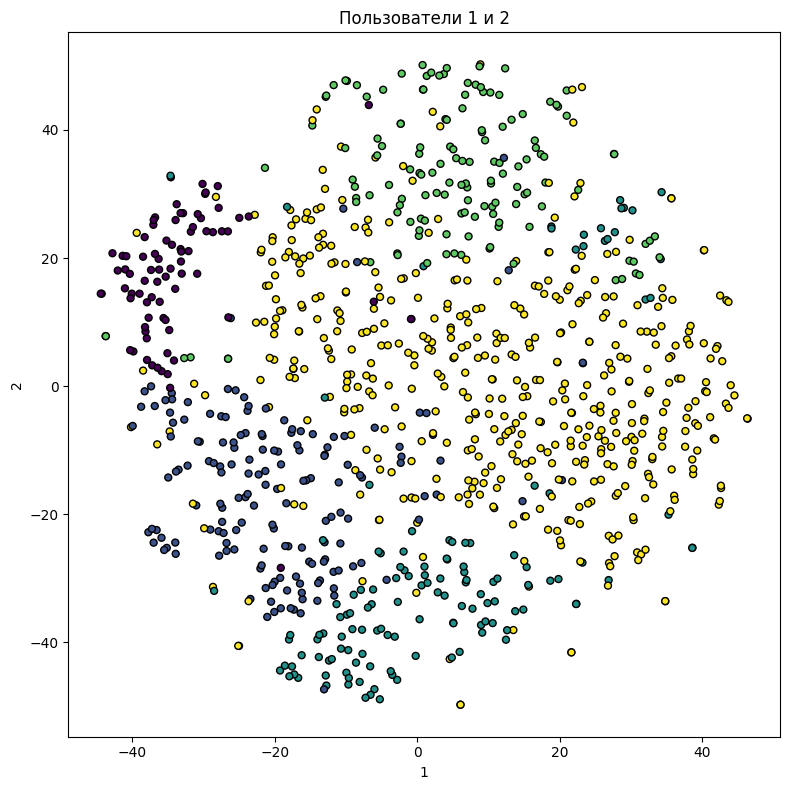

In [ ]:
from sklearn.manifold import TSNE


projection = TSNE(n_components=2, random_state=42)
embedded_coords = projection.fit_transform(ratings_normalized)
x_pos = embedded_coords[:, 0]
y_pos = embedded_coords[:, 1]
fig, canvas = plt.subplots(figsize=(8, 8))
canvas.scatter(x_pos, y_pos, c=clusters, s=25, edgecolor='k')
canvas.set_title("Пользователи 1 и 2")
canvas.set_xlabel("1")
canvas.set_ylabel("2")

plt.tight_layout()
plt.show()

Все кластеры как-то скучкованы, кроме желтого, он есть везде, хотя централизован боле к правой стороне.

## Подбор гиперпараметров

Подберем оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта.

In [ ]:
from sklearn.metrics import silhouette_score



top_k = None
max_val = -1

for n in range(2, 100):
    model = KMeans(n_clusters=n, random_state=42)
    assigned = model.fit_predict(ratings_normalized)
    val = silhouette_score(ratings_normalized, assigned)

    if val > max_val:
        max_val = val
        top_k = n

print(f'Лучшая метрика: {max_val}, число кластеров: {top_k}')



Лучшая метрика: 0.01332710844154191, число кластеров: 98


Выведем исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? 

In [ ]:


model = KMeans(n_clusters=top_k, random_state=42)
model.fit(ratings_normalized)
labels = model.predict(ratings_normalized)
centers = model.cluster_centers_

closest_artists = {}

for cluster_id, point in enumerate(centers):
    similarities = []
    for i, profile in enumerate(ratings_normalized):
        similarity = cosine(point, profile)
        name = ratings.index[i]
        similarities.append((name, similarity))

    nearest = sorted(similarities, key=lambda pair: pair[1])[:10]
    closest_artists[cluster_id] = [name for name, _ in nearest]

for group, artists in closest_artists.items():
    print(f"Кластер {group}:")
    print(', '.join(artists))
    print()

Группа 0:
dr. dre, the faint, violent femmes, margot and the nuclear so and sos, owen, the bloodhound gang, cursive, van hallen, bright eyes, ironand wine

Группа 1:
john mayer, matt nathanson, gavin degraw, jason mraz, ray lamontagne, joshua radin, sara bareilles, augustana, maroon5, o.a.r.

Группа 2:
white stripes, beck, the raconteurs, spoon, the pixies, the strokes, the flaming lips, cake, black rebel motorcycle club, gorillaz

Группа 3:
fugazi, jawbreaker, sleater-kinney, les savy fav, capn jazz, bad brains, blonde redhead, propagandhi, the melvins, gogol bordello

Группа 4:
ryan adams, band of horses, ryan adams and the cardinals, rogue wave, my morning jacket, matt pond pa, cloud cult, the american analog set, nada surf, tv on the radio

Группа 5:
dj shadow, rjd2, amon tobin, jedi mind tricks, el-p, aphex twin, sublime, moby*, gnarls barkley, soul coughing

Группа 6:
system of a down, koЯn, mudvayne, limpt bizkit, disturbed, slipknot, papa roach, godsmack, marilyn manson, fort m

 Теперь классификация более полная и похожа на правду. Например, кластер 17:
the cure, the smiths, new order, morrissey, depeche Мode, echo and the bunnymen, oy division, siouxsie and the banshees, cocteau twins, erasure - это ньювейв, чуть чуть уходящий в готический рок.

кластер 54:
slayer, iron maiden, megadeth, metallica, judas priest, black sabbath, pantera, municipal waste, motörhead, blind guardian - это металл.
Можно сказать, что смысл остался такой же - они объединяются по жанрам.


Сделайте t-SNE визуализацию полученной кластеризации.

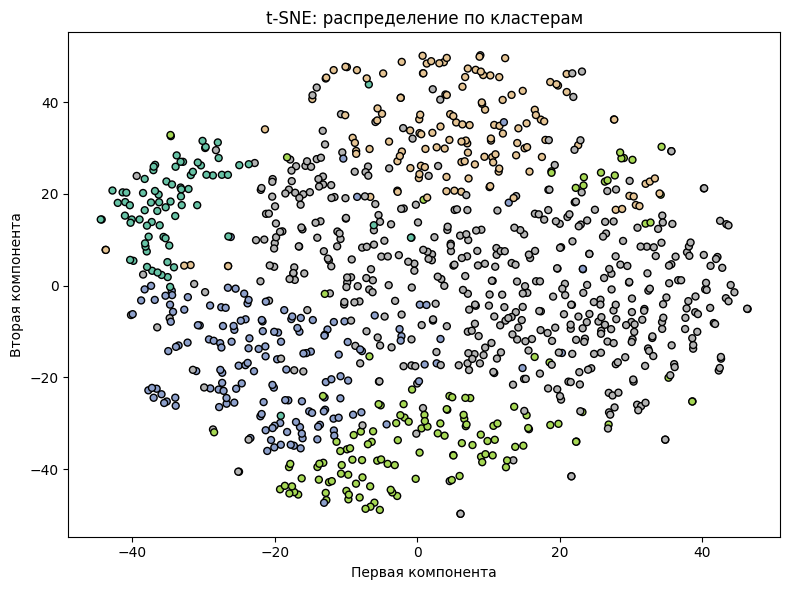

In [ ]:

x_vals = embedded_coords[:, 0]
y_vals = embedded_coords[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=clusters, cmap='Set2', s=25, edgecolor='k')
plt.title("t-SNE: распределение по кластерам")
plt.xlabel("Первая компонента")
plt.ylabel("Вторая компонента")
plt.tight_layout()
plt.show()

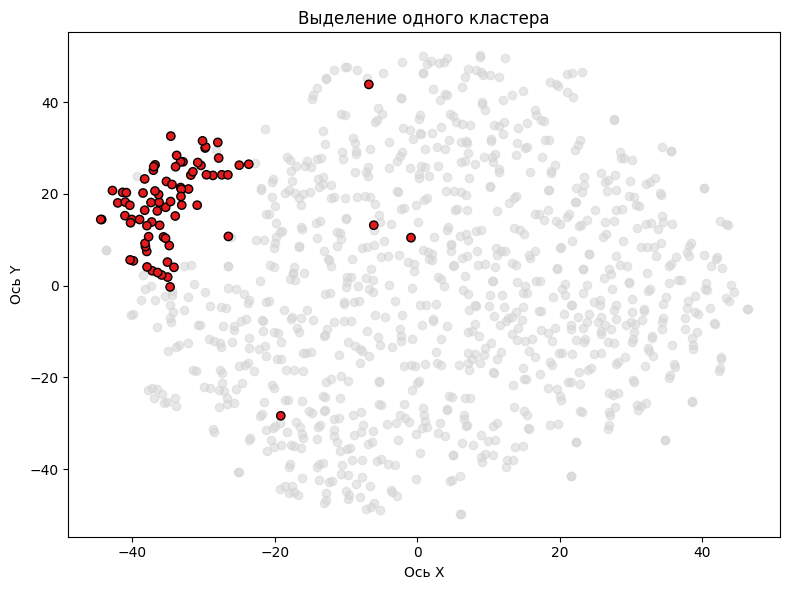

In [ ]:

x_coord = embedded_coords[:, 0]
y_coord = embedded_coords[:, 1]

highlight = clusters == 0
base_layer = clusters != 0

plt.figure(figsize=(8, 6))
plt.scatter(x_coord[base_layer], y_coord[base_layer], color='lightgray', alpha=0.5)
plt.scatter(x_coord[highlight], y_coord[highlight], c=clusters[highlight], cmap='Set1', edgecolor='k')

plt.xlabel("Ось X")
plt.ylabel("Ось Y")
plt.title("Выделение одного кластера")
plt.tight_layout()
plt.show()

 Кластер определился относительно нормально (т.н. кучковато), но все равно есть 4 исполнителя, которые располагаются слишком далеко.